In [ ]:
# Compare benchmark-FATES difference

In [1]:
import numpy as np
from scipy import stats
#
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
#
import shapefile
from shapely.geometry import shape
import shapely.vectorized
## this next library contains some helper functions for reshaping FATES variables into easier to work with dimensions
import ctsm_py
import ctsm_py.fates_xarray_funcs as fa       
#
import textwrap
from cmcrameri import cm
import cartopy
import cartopy.crs as ccrs
from cartopy.io.shapereader import Reader
#
import shapefile
import shapely
from shapely.geometry import shape

ERROR 1: PROJ: proj_create_from_database: Open of /global/homes/j/jkowalcz/.conda/envs/myenv/share/proj failed


In [2]:
plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['figure.autolayout'] = False
plt.rcParams['font.size'] = 16
##plt.rcParams['text.usetex'] = True
plt.rcParams['figure.dpi'] = 300

In [3]:
min_lat_plotting = -22.
max_lat_plotting = 12.
min_lon_plotting = 360.-82.
max_lon_plotting = 360.-42.

geog_range_plotting = [min_lon_plotting, max_lon_plotting, min_lat_plotting, max_lat_plotting]


In [4]:
# Shapefile for Amazon ecoregion
Amazon_shapefile='/global/homes/j/jkowalcz/shapefileamazonecoregionwwf/amazon_ecolola.shp'

In [5]:
# read in FATES output
fates_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/SummaryFiles/'
fates_tag='hydro_comp_bmort_kmax_tune_sapflow_kmax3_5xHR_fixSLA_vcmax40.55_fixHR_branch'
fates_file=fates_tag+'.elm.h0.cat.nc'
fates = xr.open_dataset(fates_path+fates_file)

In [6]:
def make_shapefile_mask(shapefile_path,dataset):
    r = shapefile.Reader(shapefile_path)
    polygon = shape(r.shapes()[0])

    # Standardize longitudes to the -180 to 180 range 
    lon_standardized = ((dataset.lon.values + 180) % 360) - 180

    #Create a 2D grid of your coordinates automatically
    lon_2d, lat_2d = np.meshgrid(lon_standardized, dataset.lat.values)

    #Vectorized polygon check 
    mask_numpy = shapely.vectorized.contains(polygon, lon_2d, lat_2d)

    #Convert it back into a xarray DataArray matching given dataset
    Mask = xr.DataArray(
        mask_numpy.astype(int), 
        coords=[dataset.lat, dataset.lon], 
        dims=["lat", "lon"]
    )

    return Mask

In [7]:
fates_Amazon_mask=make_shapefile_mask(Amazon_shapefile,fates)

In [8]:
# FLII-masked, regridded benchmarking files are here:
in_path='/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/Regridded_Regional_Files/'

In [9]:
# Above-Ground Carbon Biomass
# convert kg C/m2 to Mg C/ha
fates_agcb=10*fates.FATES_VEGC_ABOVEGROUND.mean(dim='time') # kg C/m2

In [58]:
# AGCB datasets: CTrees, ESACCI, GEDI, GEOCARBON, Ometto el al (2023)
ctrees_agcb=xr.open_dataset(in_path+'CTrees_biomass_Amazon_regional_avg2000-2014.nc')
esacci_agcb=xr.open_dataset(in_path+'esacci_biomass.nc')
gedi_agcb=xr.open_dataset(in_path+'OLS_C50_Amazon_ALL_AGB_mean_nonull_cut.nc')
geocarbon_agcb=xr.open_dataset(in_path+'geocarbon_biomass.nc')
ometto_agcb=xr.open_dataset(in_path+'Ometto2023_biomass_Mgha_WGS84.nc')

In [70]:
geocarbon_agcb=geocarbon_agcb.mean(dim='time')

In [59]:
geocarbon_agcb=geocarbon_agcb.rename({"__xarray_dataarray_variable__": "biomass"})


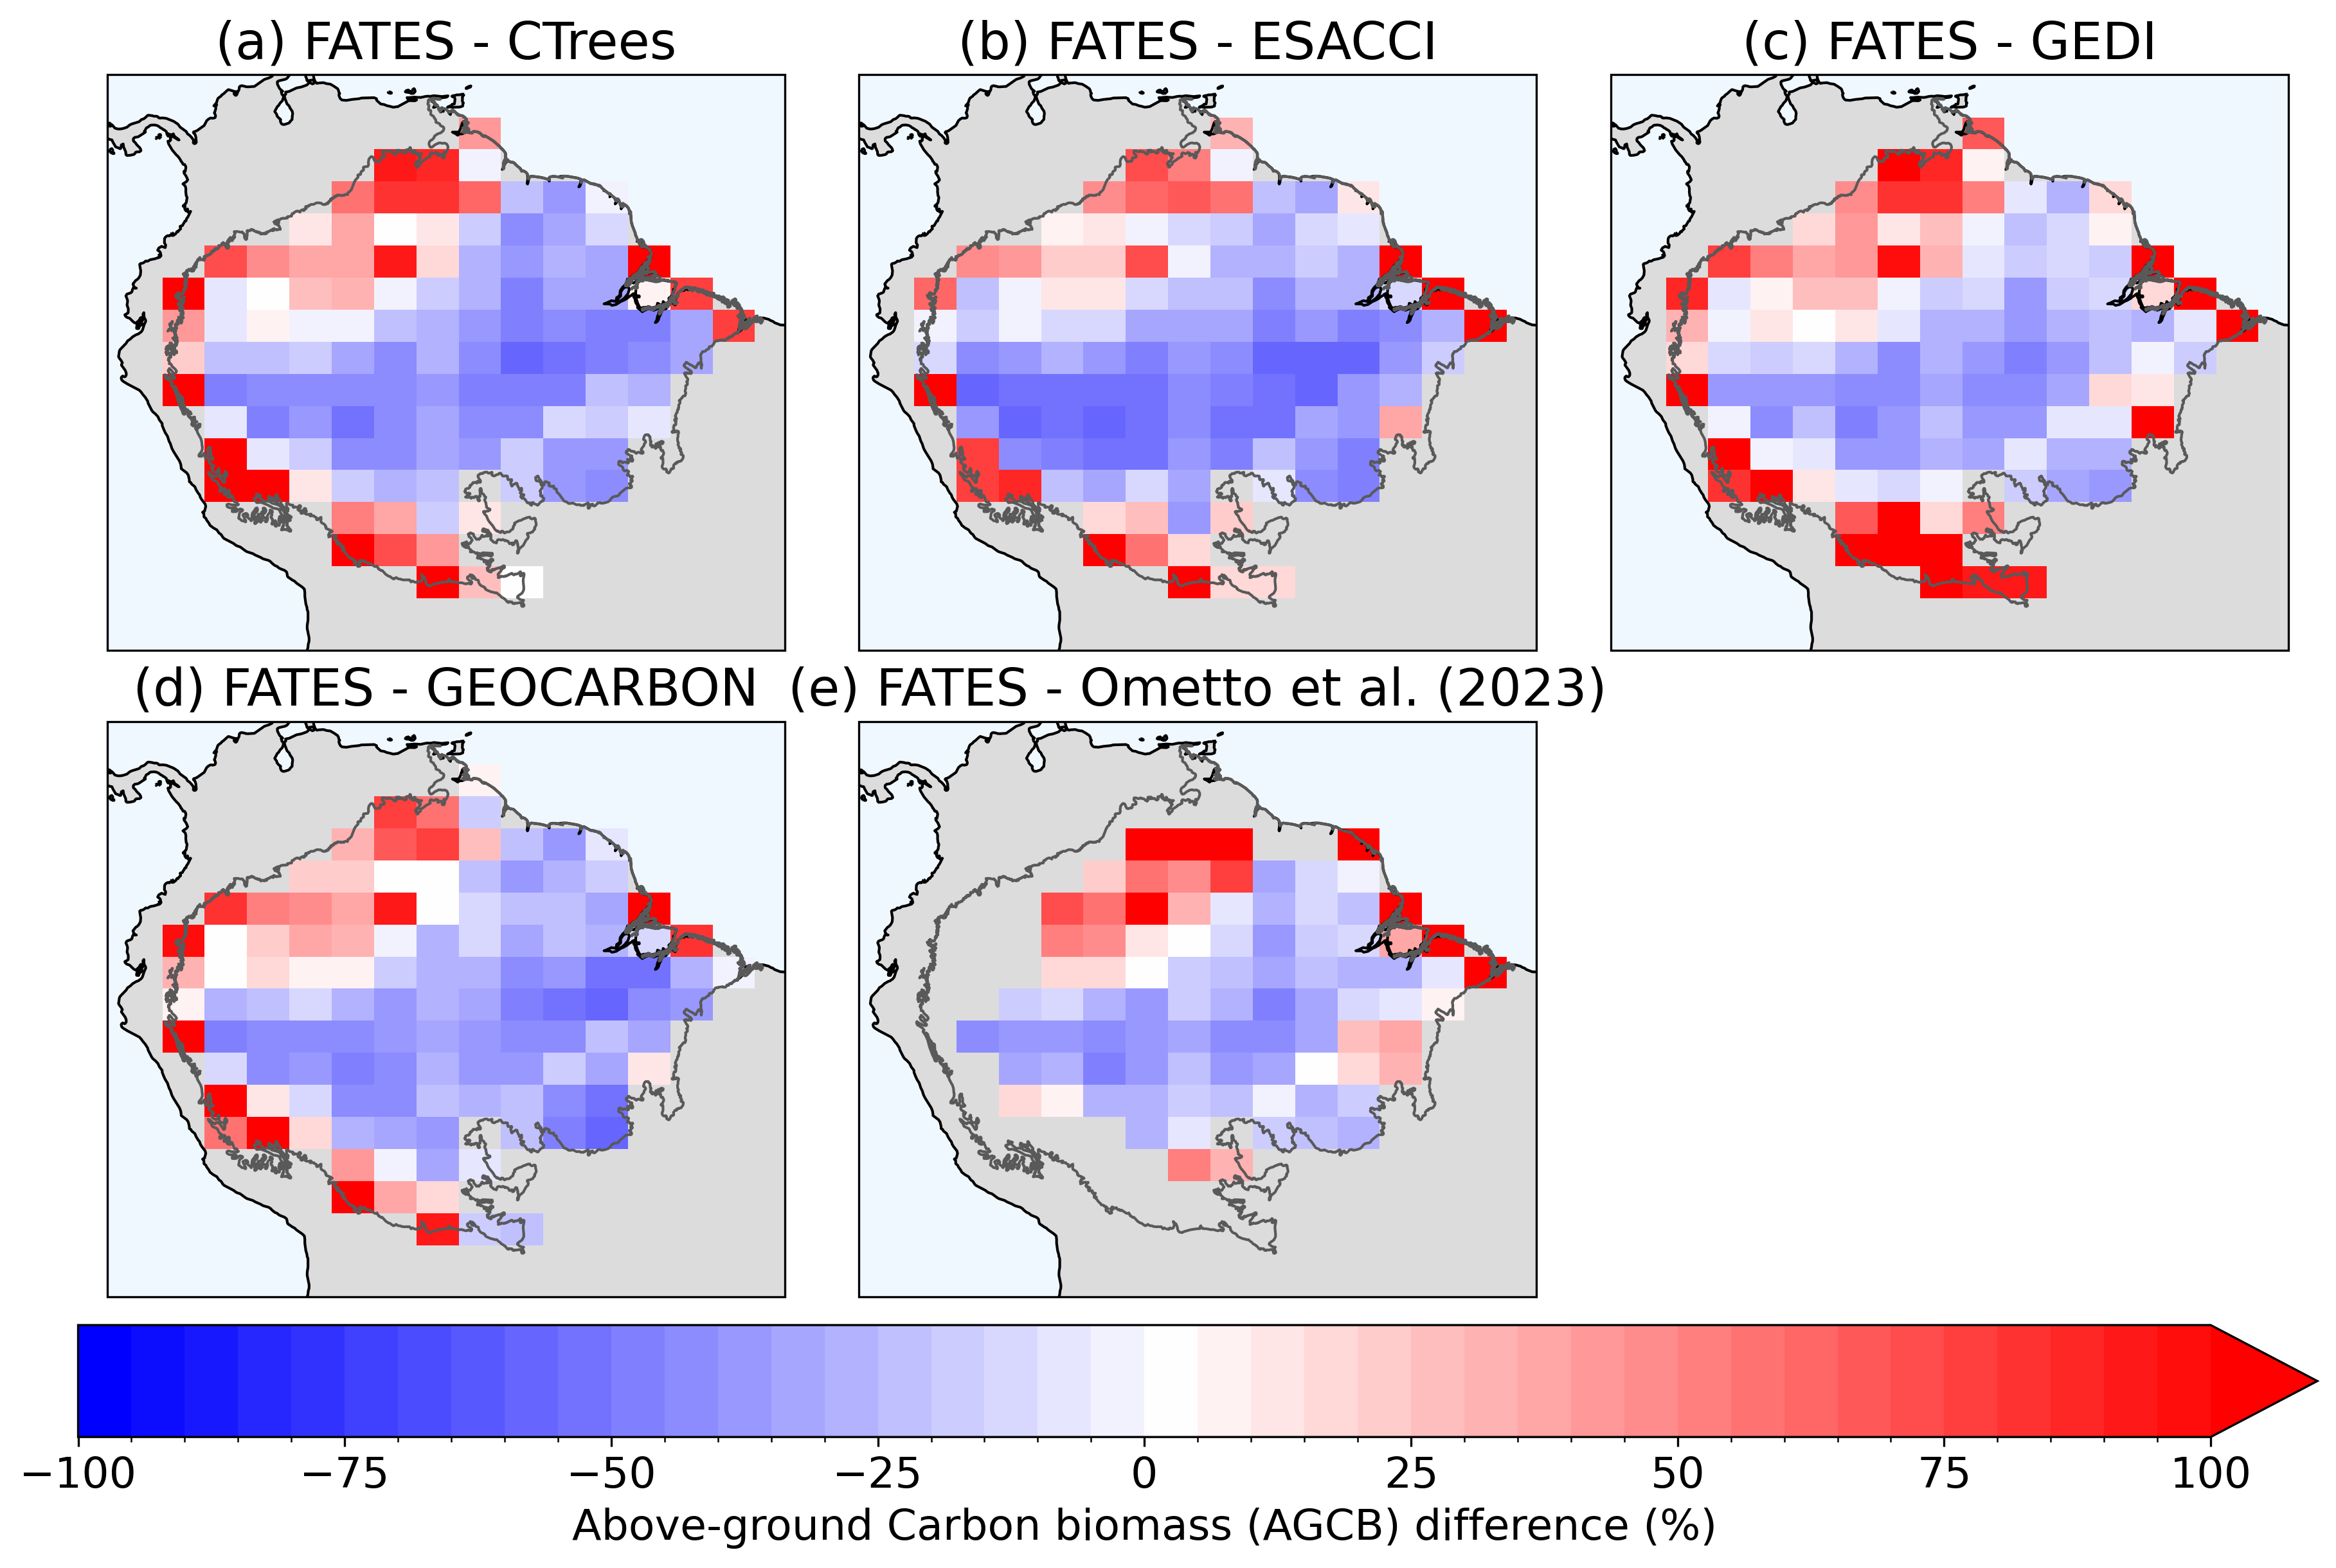

In [71]:
# Make a 5 panel figure for AGCB % differences

# Create figure with 5 subplots (2 row, 3 columns)
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
# Hide the unused 6th subplot
ax6.set_visible(False)

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - CTrees)/CTrees
ctrees_diff = 100 * (fates_agcb - ctrees_agcb) / ctrees_agcb
im1 = ctrees_diff.biomass.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - CTrees")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - ESACCI)/ESACCI
esacci_diff = 100 * (fates_agcb - esacci_agcb) / esacci_agcb
im2 = esacci_diff.biomass.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - ESACCI")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - GEDI)/GEDI
gedi_diff = 100 * (fates_agcb - gedi_agcb) / gedi_agcb
im3 = gedi_diff.biomass.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - GEDI")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Fourth panel: (FATES - GEOCARBON)/GEOCARBON
geocarbon_diff = 100 * (fates_agcb - geocarbon_agcb) / geocarbon_agcb
im4 = geocarbon_diff.biomass.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax4,
    add_colorbar=False,  # Turn off individual colorbar
)
ax4.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax4.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax4.set_title("(d) FATES - GEOCARBON")
ax4.coastlines()
ax4.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax4.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax4.set_ylim([min_lat_plotting, max_lat_plotting])

# Fifth panel: (FATES - Ometto)/Ometto
ometto_diff = 100 * (fates_agcb - ometto_agcb) / ometto_agcb
im5 = ometto_diff.biomass.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax5,
    add_colorbar=False,  # Turn off individual colorbar
)
ax5.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax5.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax5.set_title("(e) FATES - Ometto et al. (2023)")
ax5.coastlines()
ax5.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax5.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax5.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="horizontal",
    shrink=1,
    pad=0.02,
    label="Above-ground Carbon biomass (AGCB) difference (%)",
)

In [72]:
np.nanmean(np.concatenate((ctrees_diff.biomass.where(fates_Amazon_mask > 0).data,
                          esacci_diff.biomass.where(fates_Amazon_mask > 0).data,
                          gedi_diff.biomass.where(fates_Amazon_mask > 0).data,
                          geocarbon_diff.biomass.where(fates_Amazon_mask > 0).data,
                          ometto_diff.biomass.where(fates_Amazon_mask > 0).data)))

4.3029376063308

In [73]:
np.nanstd(np.concatenate((ctrees_diff.biomass.where(fates_Amazon_mask > 0).data,
                          esacci_diff.biomass.where(fates_Amazon_mask > 0).data,
                          gedi_diff.biomass.where(fates_Amazon_mask > 0).data,
                          geocarbon_diff.biomass.where(fates_Amazon_mask > 0).data,
                          ometto_diff.biomass.where(fates_Amazon_mask > 0).data)))

61.033674717509996

In [62]:
np.std(ctrees_diff.biomass.where(fates_Amazon_mask > 0))

<xarray.DataArray 'biomass' ()>
array(64.95974847)
Coordinates:
    spatial_ref  int64 0

In [47]:
# This is correct:
#ilamb_dir="/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/ILAMB/"
#test=xr.open_dataset(ilamb_dir + 'CTrees_biomass_Amazon_regional_avg2000-2014.nc')

# this is now correct:
out_dir="/pscratch/sd/j/jkowalcz/e3sm_scratch/pm-cpu/Benchmarks/FLII_Masked_Regional_Files/"
test=xr.open_dataset(out_dir + 'CTrees_biomass_Amazon_regional_avg2000-2014.nc')


In [48]:
test

<xarray.Dataset>
Dimensions:      (lon: 4326, lat: 3765)
Coordinates:
  * lon          (lon) float64 -80.85 -80.84 -80.83 ... -42.02 -42.01 -42.0
  * lat          (lat) float64 11.82 11.81 11.8 11.79 ... -21.98 -21.99 -21.99
    spatial_ref  int64 ...
Data variables:
    biomass      (lat, lon) float32 ...

Text(0.5, 1.0, 'CTrees AGCB avg 2000-2014')

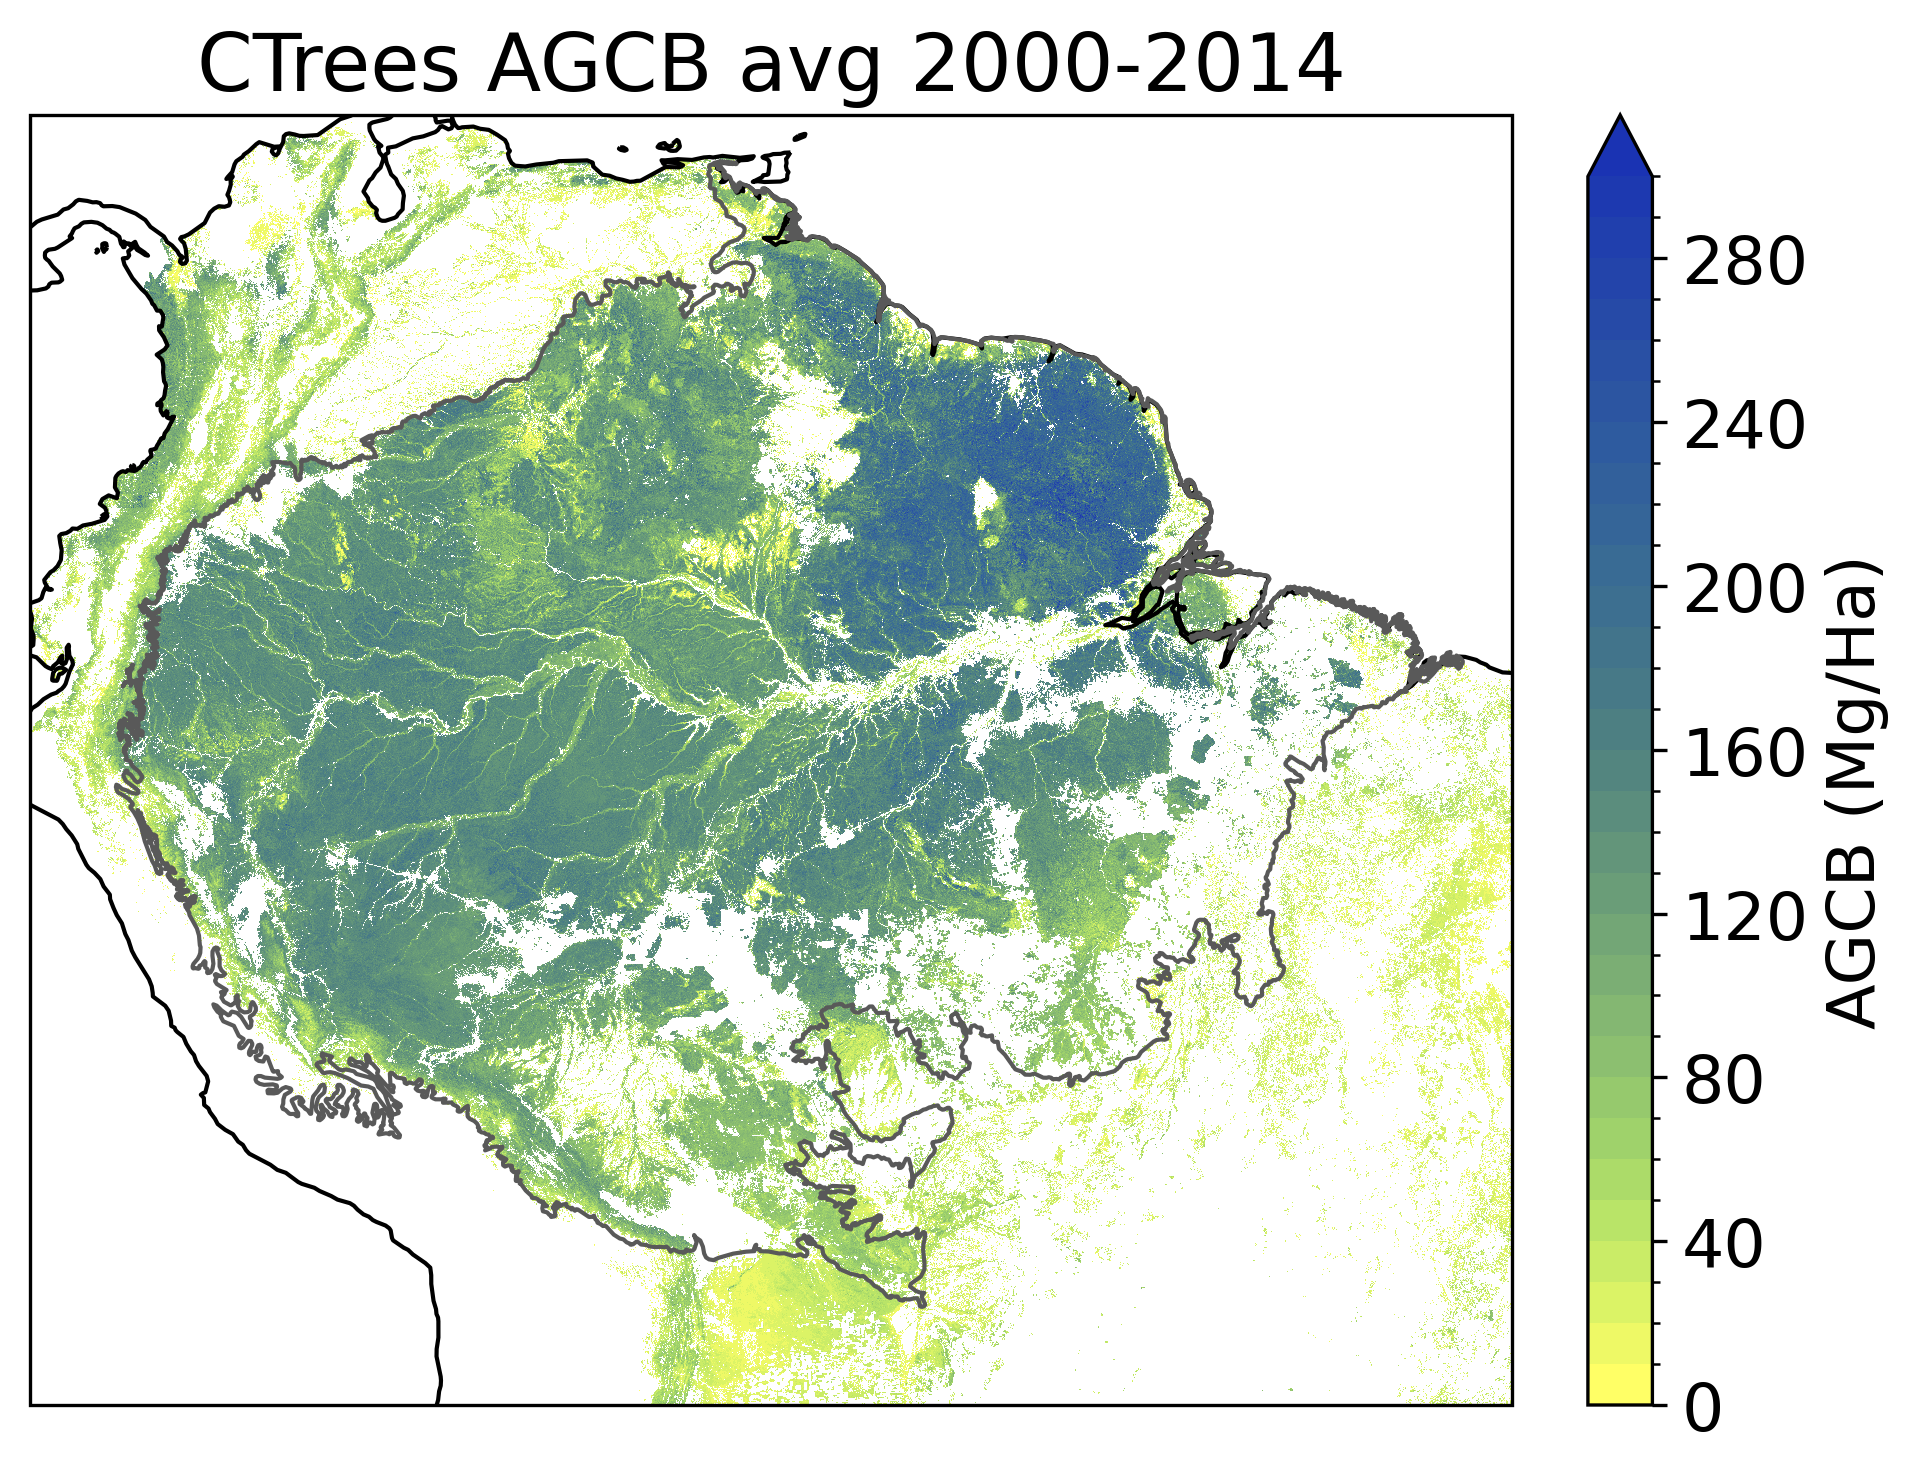

In [49]:
ax = plt.subplot(projection=ccrs.PlateCarree())
test.biomass.plot(levels=np.linspace(0,300,31),cmap=cm.imola_r,cbar_kwargs=dict(shrink=1,location='right',orientation='vertical',label='AGCB (Mg/Ha)'))
ax.coastlines()
ax.add_geometries(Reader(Amazon_shapefile).geometries(),ccrs.PlateCarree(),edgecolor=(0.35,0.35,0.35,1),facecolor=(0,0,0,0))
plt.title('CTrees AGCB avg 2000-2014')


In [115]:
# leaf area index
fates_lai=fates.FATES_LAI.mean(dim='time')

In [117]:
# LAI datasets: AVH15C1, AVHRR, Cao2023, GEDI, MODIS
avh15c1_lai=xr.open_dataset(in_path+'AVH15C1_lai.nc') # subset over 1990-2014
avhrr_lai=xr.open_dataset(in_path+'avhrr_lai_0.5x0.5.nc') # subset over 1990-2010
cao_lai = xr.open_dataset(in_path+'cao2023_lai.nc') # subset over 1990-2014
gedi_lai=xr.open_dataset(in_path+'OLS_C50_Amazon_ALL_LAI_mean_nonull_cut.nc') # what year is this from?
modis_lai=xr.open_dataset(in_path+'ilamb_modis_lai_0.5x0.5.nc') # 2000-2005

In [122]:
avh15c1_lai=avh15c1_lai.rename({"__xarray_dataarray_variable__": "lai"})
gedi_lai=gedi_lai.rename({"__xarray_dataarray_variable__": "lai"})


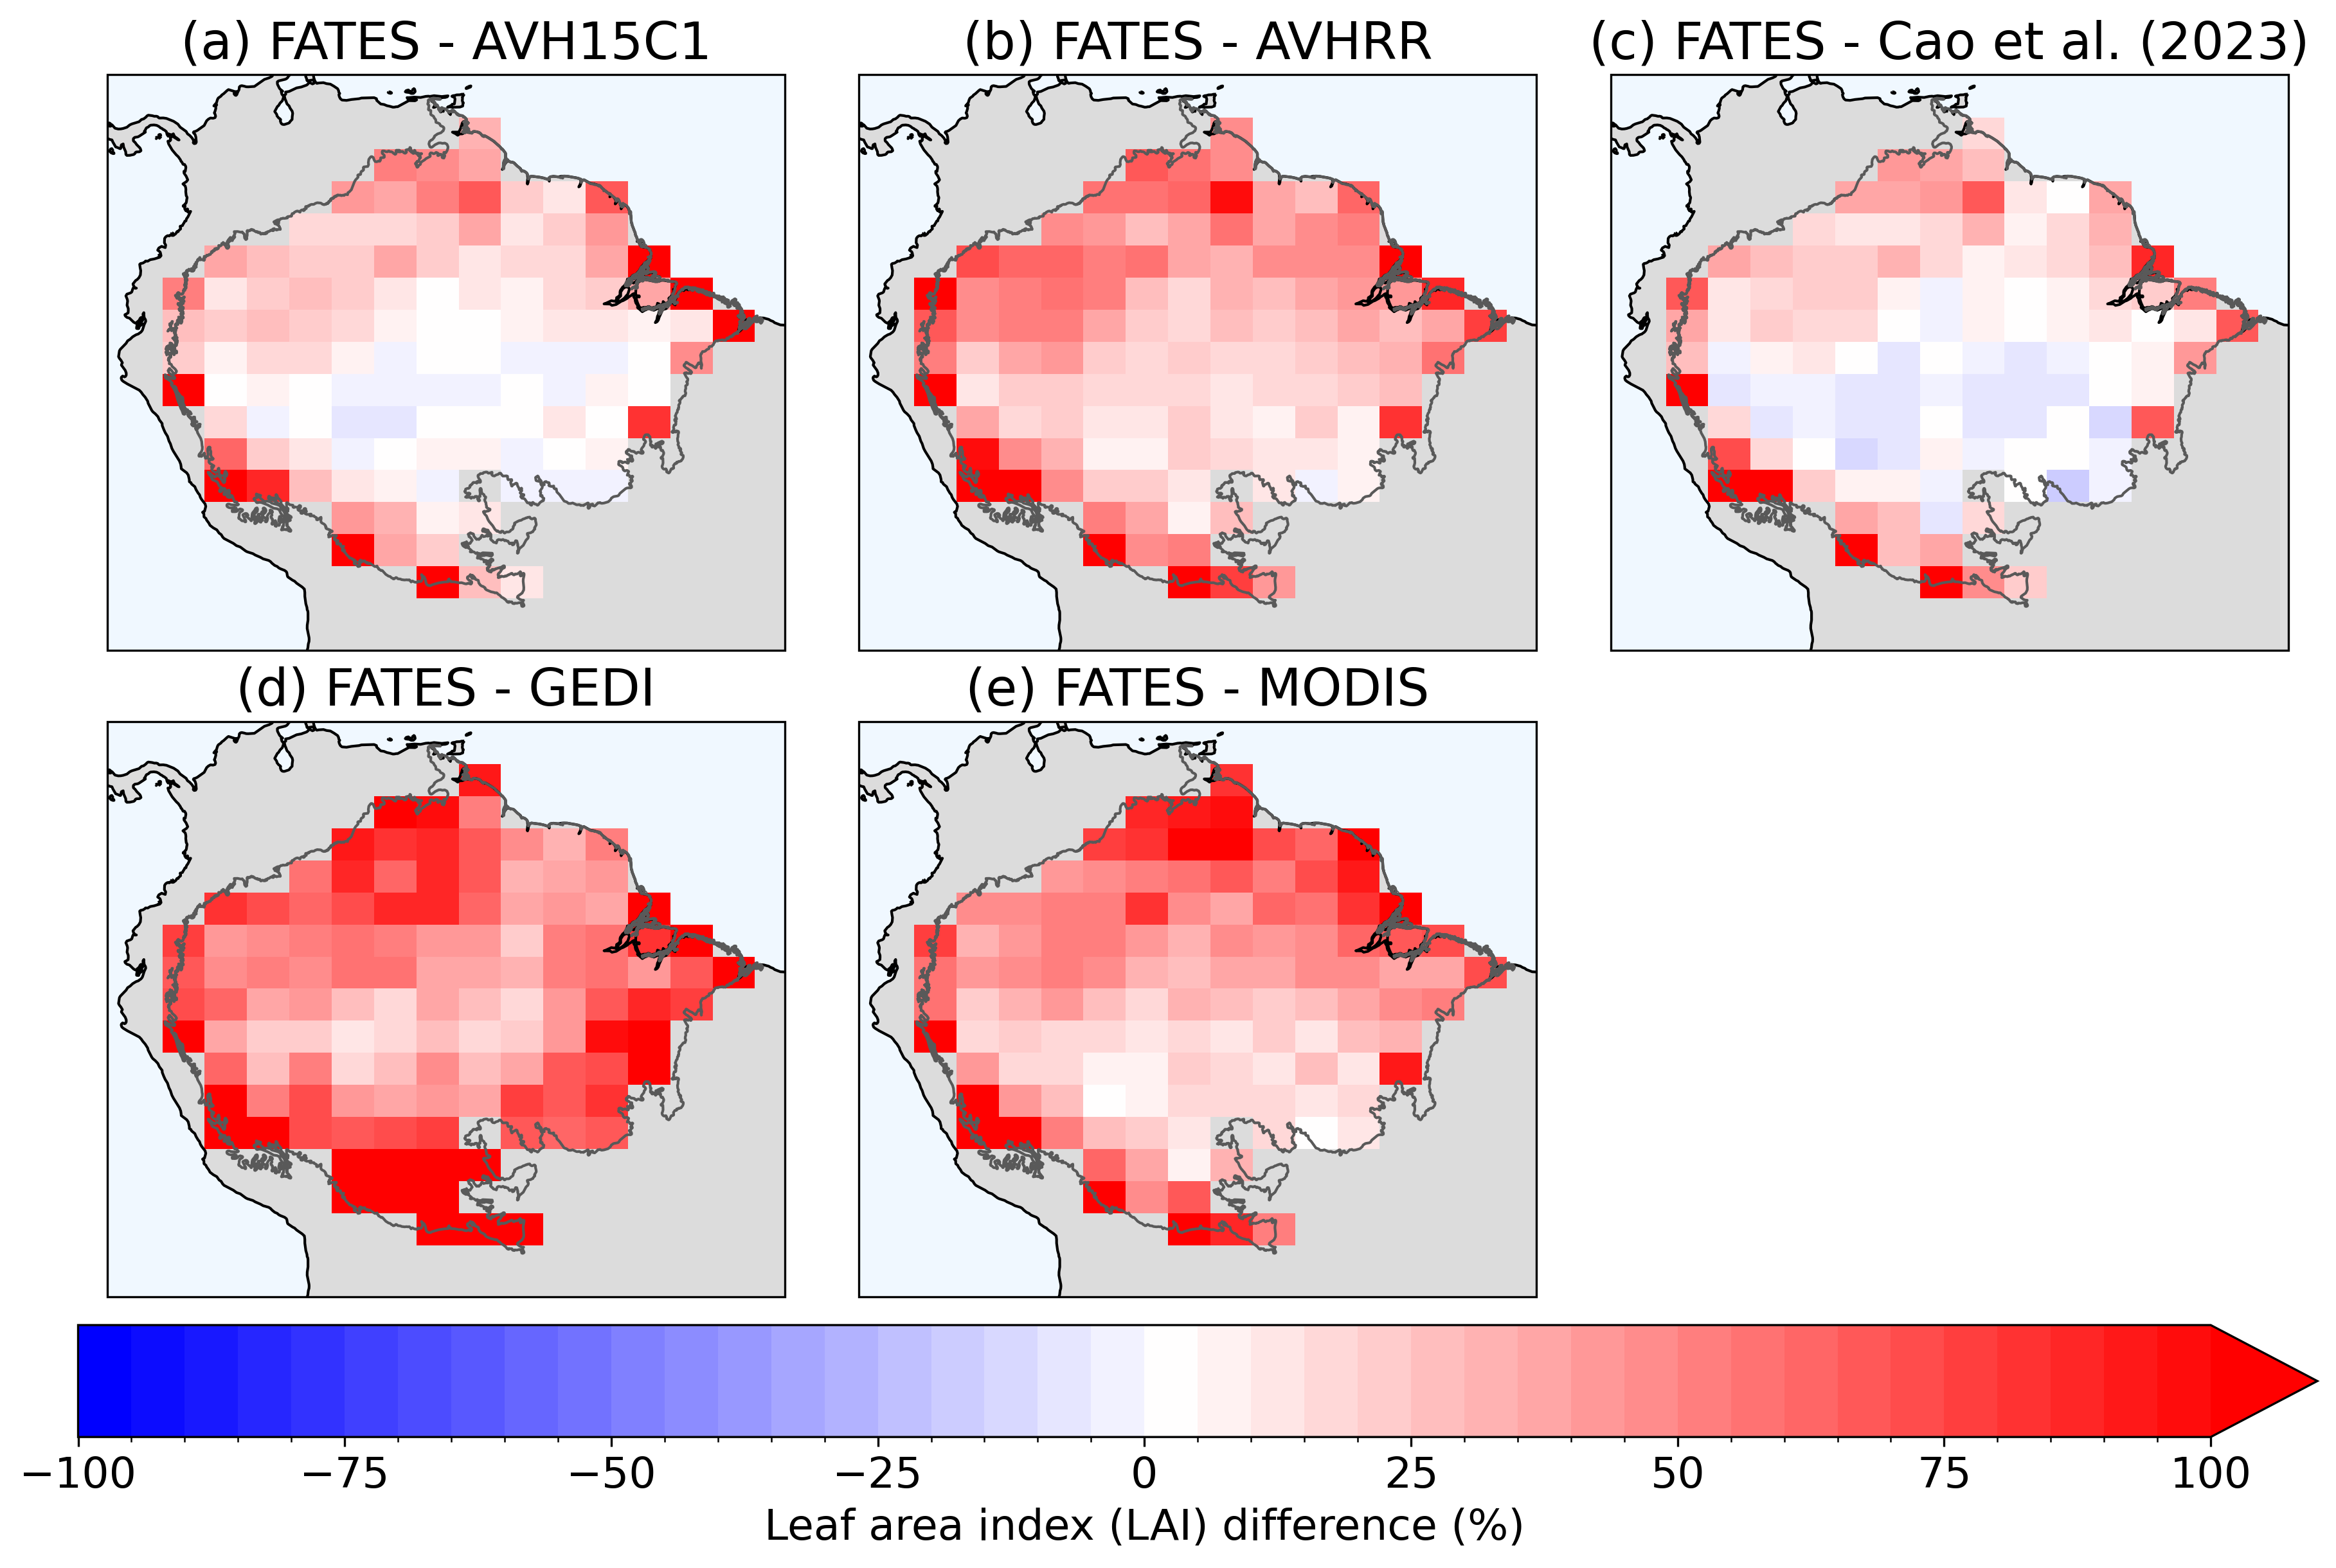

In [132]:
# Make a 5 panel figure for LAI % differences

# Create figure with 5 subplots (2 row, 3 columns)
fig, axes = plt.subplots(
    2,
    3,
    figsize=(12, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3, ax4, ax5, ax6 = axes.flatten()
# Hide the unused 6th subplot
ax6.set_visible(False)

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - AVH15C1)/AVH15C1
avh15c1_diff = 100 * (fates_lai - avh15c1_lai) / avh15c1_lai
im1 = avh15c1_diff.lai.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - AVH15C1")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - AVHRR)/AVHRR
avhrr_diff = 100 * (fates_lai - avhrr_lai) / avhrr_lai
im2 = avhrr_diff.lai.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - AVHRR")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - Cao)/Cao
cao_diff = 100 * (fates_lai - cao_lai) / cao_lai
im3 = cao_diff.lai.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - Cao et al. (2023)")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Fourth panel: (FATES - GEDI)/GEDI
gedi_diff = 100 * (fates_lai - gedi_lai) / gedi_lai
im4 = gedi_diff.lai.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax4,
    add_colorbar=False,  # Turn off individual colorbar
)
ax4.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax4.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax4.set_title("(d) FATES - GEDI")
ax4.coastlines()
ax4.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax4.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax4.set_ylim([min_lat_plotting, max_lat_plotting])

# Fifth panel: (FATES - MODIS)/MODIS
modis_diff = 100 * (fates_lai - modis_lai) / modis_lai
im5 = modis_diff.lai.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax5,
    add_colorbar=False,  # Turn off individual colorbar
)
ax5.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax5.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax5.set_title("(e) FATES - MODIS")
ax5.coastlines()
ax5.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax5.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax5.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="horizontal",
    shrink=1,
    pad=0.02,
    label="Leaf area index (LAI) difference (%)",
)

In [146]:
np.nanmean(np.concatenate((avh15c1_diff.lai.where(fates_Amazon_mask > 0),avhrr_diff.lai.where(fates_Amazon_mask > 0),
                          cao_diff.lai.where(fates_Amazon_mask > 0),gedi_diff.lai.where(fates_Amazon_mask > 0),
                          modis_diff.lai.where(fates_Amazon_mask > 0))))

42.01117621760377

In [147]:
np.nanstd(np.concatenate((avh15c1_diff.lai.where(fates_Amazon_mask > 0),avhrr_diff.lai.where(fates_Amazon_mask > 0),
                          cao_diff.lai.where(fates_Amazon_mask > 0),gedi_diff.lai.where(fates_Amazon_mask > 0),
                          modis_diff.lai.where(fates_Amazon_mask > 0))))

43.69532591484968

In [143]:
# lai stats
np.mean(modis_diff.lai.where(fates_Amazon_mask > 0))

<xarray.DataArray 'lai' ()>
array(50.70314156)

In [144]:
np.std(modis_diff.lai.where(fates_Amazon_mask > 0))

<xarray.DataArray 'lai' ()>
array(41.86360622)

In [77]:
# GPP - convert kg C /m2/s to g C/m2/day
fates_gpp=fates.FATES_GPP.mean(dim="time")*86400.*1000.  

In [99]:
# GPP datasets: FLUXCOM, GOSIF, WECANN
fluxcom_gpp = xr.open_dataset(in_path+'ilamb_fluxcom_gpp.nc') # subset to 1990-2013; gC/m2/day
fluxcom_gpp = fluxcom_gpp.rename({"__xarray_dataarray_variable__": "gpp"})
gosif_gpp = xr.open_dataset(in_path+'gosif_gpp_regional_avg.nc') # 2000-2014, gC m-2 day-1
wecann_gpp = xr.open_dataset(in_path+'wecann_gpp.nc') # # 2007 - 2015; g/m^2/day

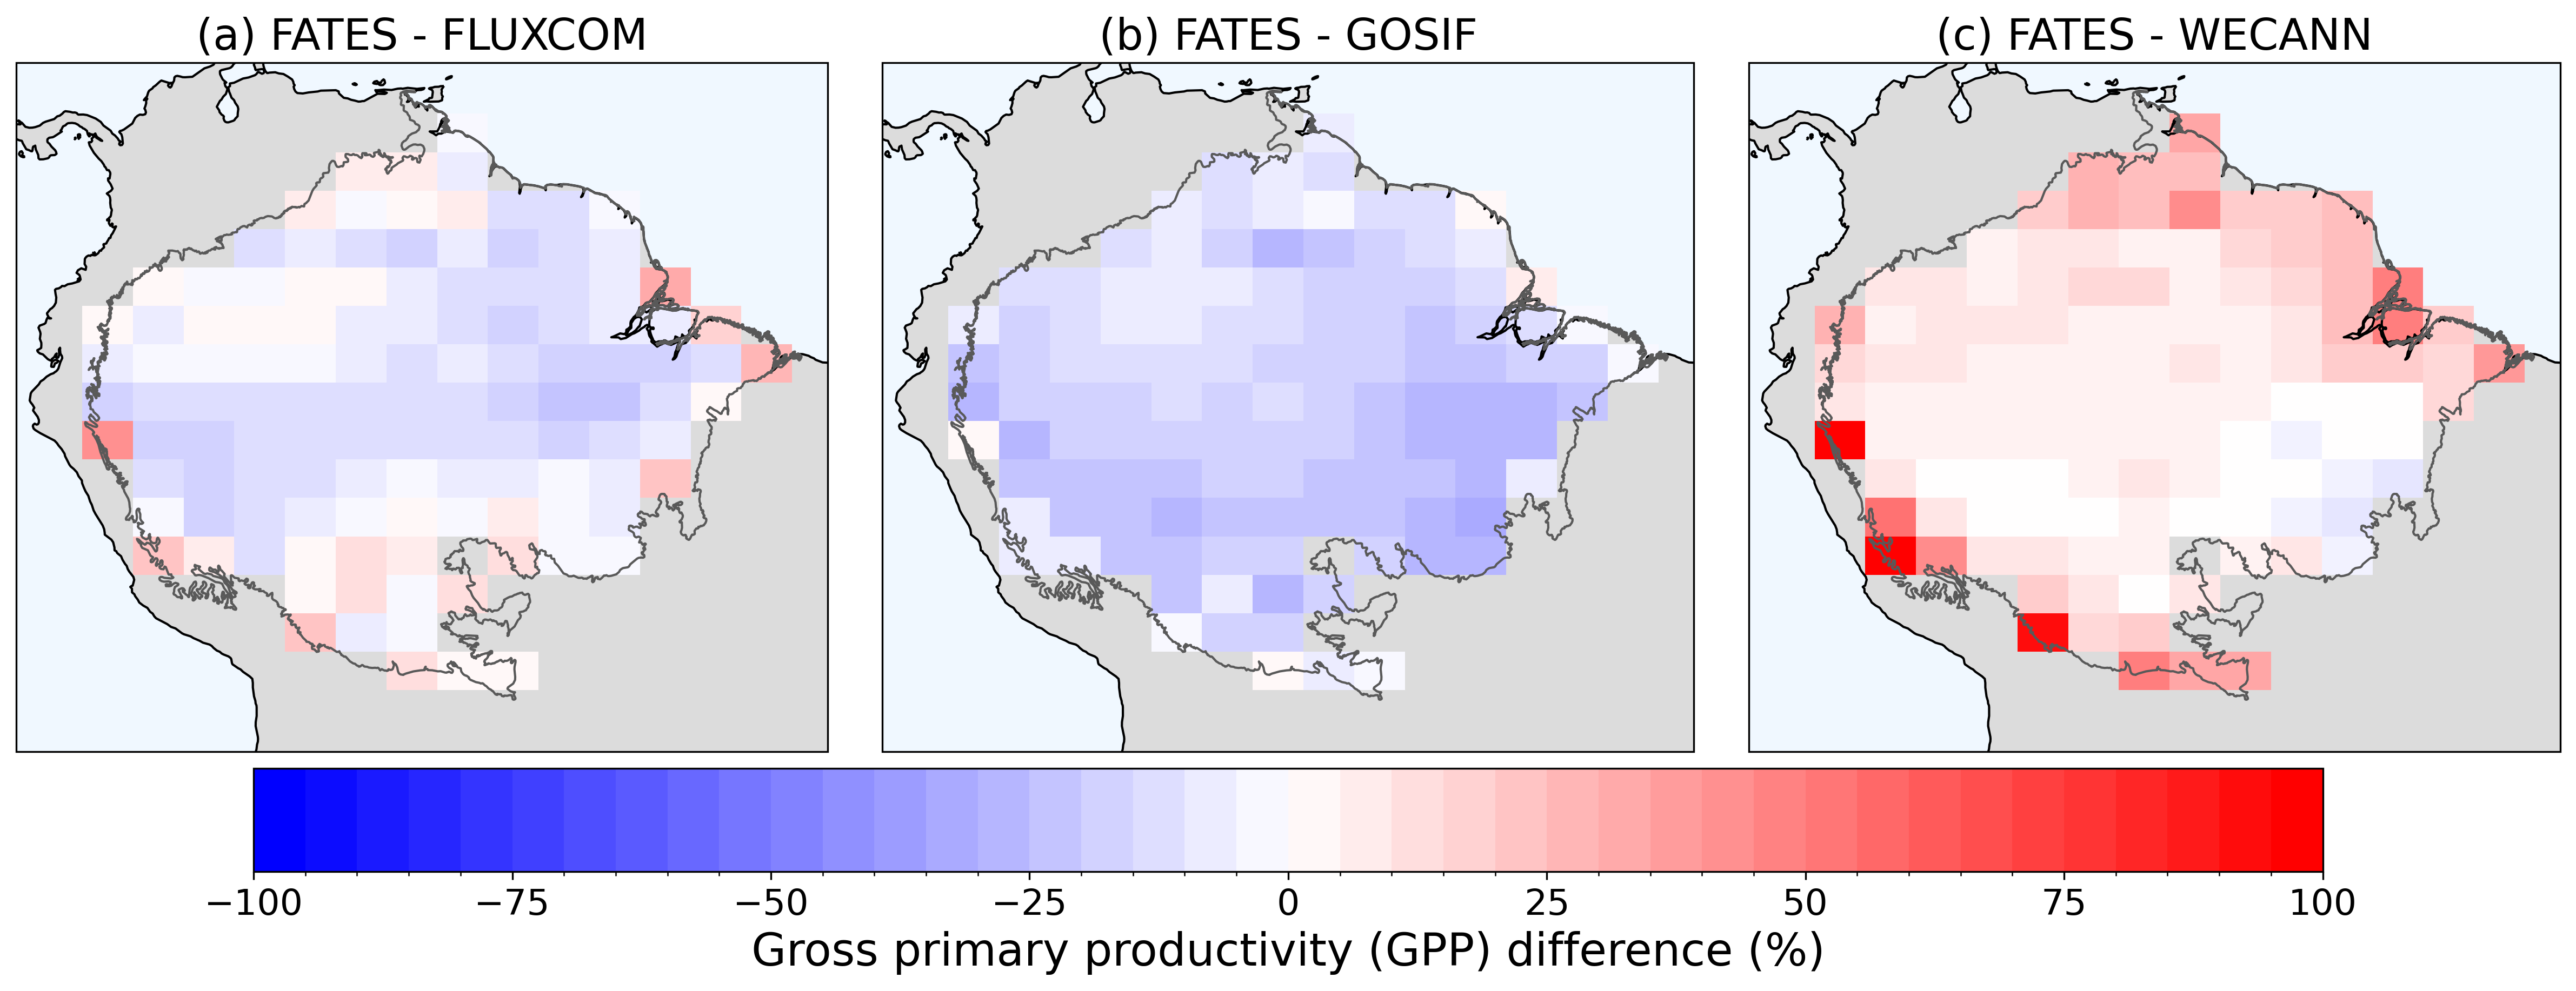

In [100]:
# Make a 3 panel figure for GPP % differences

# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3 = axes.flatten()

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - FLUXCOM)/FLUXCOM
fluxcom_diff = 100 * (fates_gpp - fluxcom_gpp) / fluxcom_gpp
im1 = fluxcom_diff.gpp.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - FLUXCOM")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - GOSIF)/GOSIF
gosif_diff = 100 * (fates_gpp - gosif_gpp) / gosif_gpp
im2 = gosif_diff.gpp.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - GOSIF")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - WECANN)/WECANN
wecann_diff = 100 * (fates_gpp - wecann_gpp) / wecann_gpp
im3 = wecann_diff.gpp.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - WECANN")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="horizontal",
    shrink=1,
    pad=0.02
)
cbar.set_label(label="Gross primary productivity (GPP) difference (%)",fontsize=20)

In [107]:
np.mean(wecann_diff.gpp.where(fates_Amazon_mask > 0))

<xarray.DataArray 'gpp' ()>
array(16.64677667)

In [109]:
np.std(wecann_diff.gpp.where(fates_Amazon_mask > 0))

<xarray.DataArray 'gpp' ()>
array(20.90770834)

In [112]:
np.nanmean(np.concatenate((fluxcom_diff.gpp.where(fates_Amazon_mask > 0).data,gosif_diff.gpp.where(fates_Amazon_mask > 0).data,wecann_diff.gpp.where(fates_Amazon_mask > 0).data))) 

-1.4541536103161705

In [113]:
np.nanstd(np.concatenate((fluxcom_diff.gpp.where(fates_Amazon_mask > 0).data,gosif_diff.gpp.where(fates_Amazon_mask > 0).data,wecann_diff.gpp.where(fates_Amazon_mask > 0).data))) 

19.823000788199217

In [16]:
## Evapotranspiration
fates_et = fates.QSOIL.mean(dim="time") + fates.QVEGE.mean(dim="time") + fates.QVEGT.mean(dim="time") #mm/s

In [13]:
## Evapotranspiration datasets: GLEAM, MOD16A2, MODIS
# Note: 1 kg/m2/s = 1 mm/s
gleam_et=xr.open_dataset(in_path+'GLEAMv3.3a_et.nc') # subset to 1990-2014; kg/m2/s 
mod16a2_et=xr.open_dataset(in_path+'MOD16A2_et.nc') # 2000-2014; kg/m2/s
modis_et=xr.open_dataset(in_path+'modis_et_0.5x0.5.nc') # 2000 - 2013; kg/m2/s

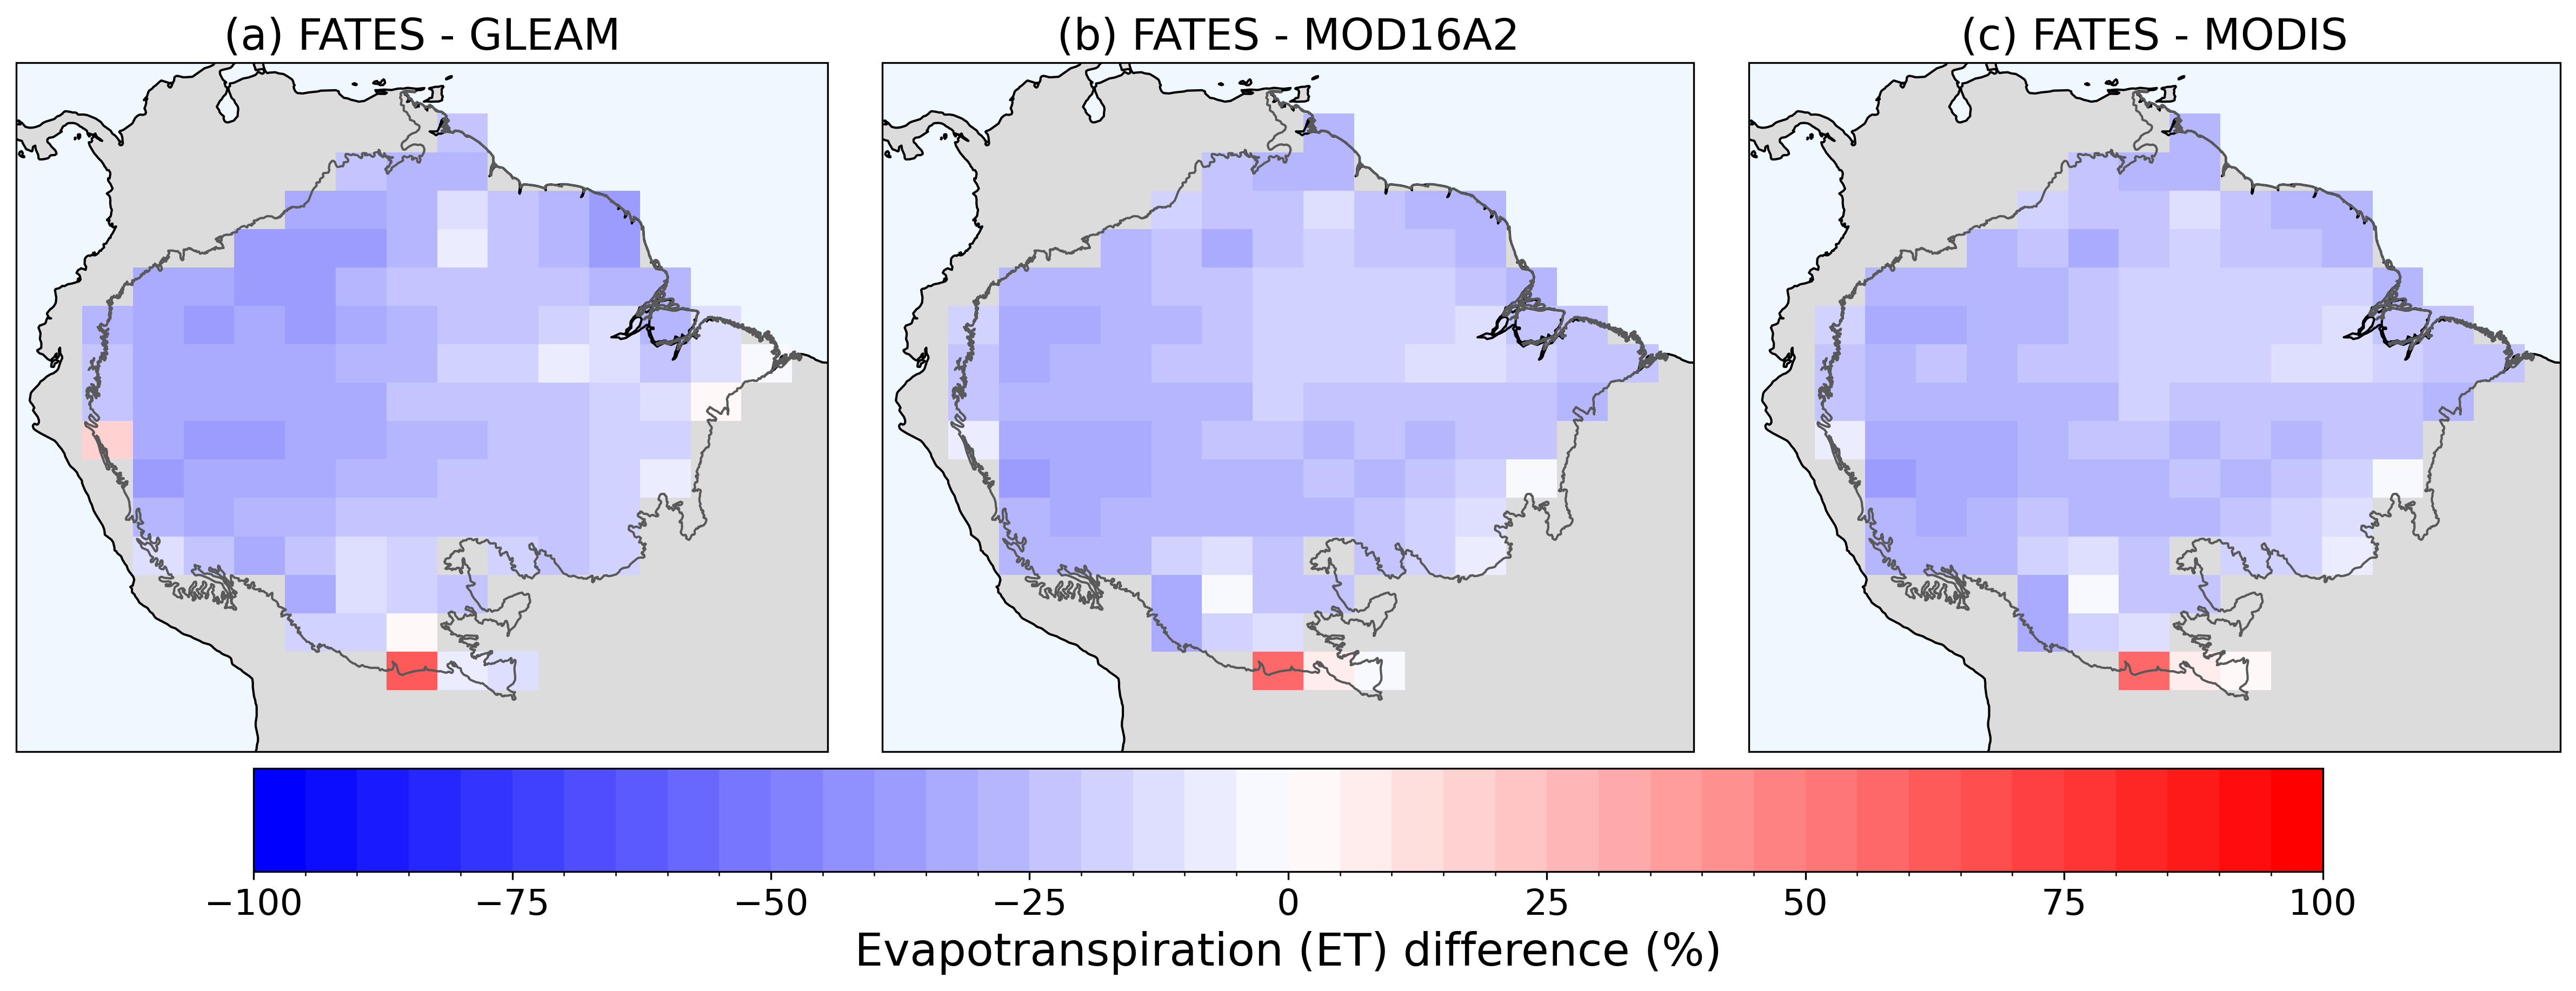

In [78]:
# Make a 3 panel figure for ET % differences

# Create figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 6),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3 = axes.flatten()

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - GLEAM)/GLEAM
gleam_diff = 100 * (fates_et - gleam_et) / gleam_et
im1 = gleam_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - GLEAM")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - MOD16A2)/MOD16A2
mod16a2_diff = 100 * (fates_et - mod16a2_et) / mod16a2_et
im2 = mod16a2_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - MOD16A2")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - MODIS)/MODIS
modis_diff = 100 * (fates_et - modis_et) / modis_et
im3 = modis_diff.et.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - MODIS")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="horizontal",
    shrink=1,
    pad=0.02
)
cbar.set_label(label="Evapotranspiration (ET) difference (%)",fontsize=20)

In [39]:
## Print stats:
np.mean(modis_diff.et.where(fates_Amazon_mask > 0))


<xarray.DataArray 'et' ()>
array(-21.62851487)

In [40]:
np.std(modis_diff.et.where(fates_Amazon_mask > 0))

<xarray.DataArray 'et' ()>
array(10.2953744)

In [90]:
# all ET
np.nanmean(np.concatenate((gleam_diff.et.where(fates_Amazon_mask > 0).data,mod16a2_diff.et.where(fates_Amazon_mask > 0).data,modis_diff.et.where(fates_Amazon_mask > 0).data)))


-22.288723562168553

In [92]:
np.nanstd(np.concatenate((gleam_diff.et.where(fates_Amazon_mask > 0).data,mod16a2_diff.et.where(fates_Amazon_mask > 0).data,modis_diff.et.where(fates_Amazon_mask > 0).data)))


10.857466817978777

In [87]:
np.mean(modis_diff.et.where(fates_Amazon_mask > 0))

<xarray.DataArray 'et' ()>
array(-21.62851487)

In [88]:
np.nanmean(modis_diff.et.where(fates_Amazon_mask > 0).data)

-21.628514872946514

In [ ]:
# Latent heat flux
# Datasets: CLASS, DOLCE, FLUXCOM, WECANN

In [42]:
fates_lh=fates.EFLX_LH_TOT.mean(dim='time') #total latent heat flux [+ to atm]; W/m2

In [43]:
class_lh=xr.open_dataset(in_path+'CLASS_LH.nc') # 2003 - 2009; W/m2
dolce_lh=xr.open_dataset(in_path+'DOLCE_LH.nc') # 2000 - 2009; W/m2
fluxcom_lh=xr.open_dataset(in_path+'fluxcom_LH.nc') # 1990 - 2014; W/m2
wecann_lh=xr.open_dataset(in_path+'WECANN_LH.nc') # 2007 - 2015 ; W/m2

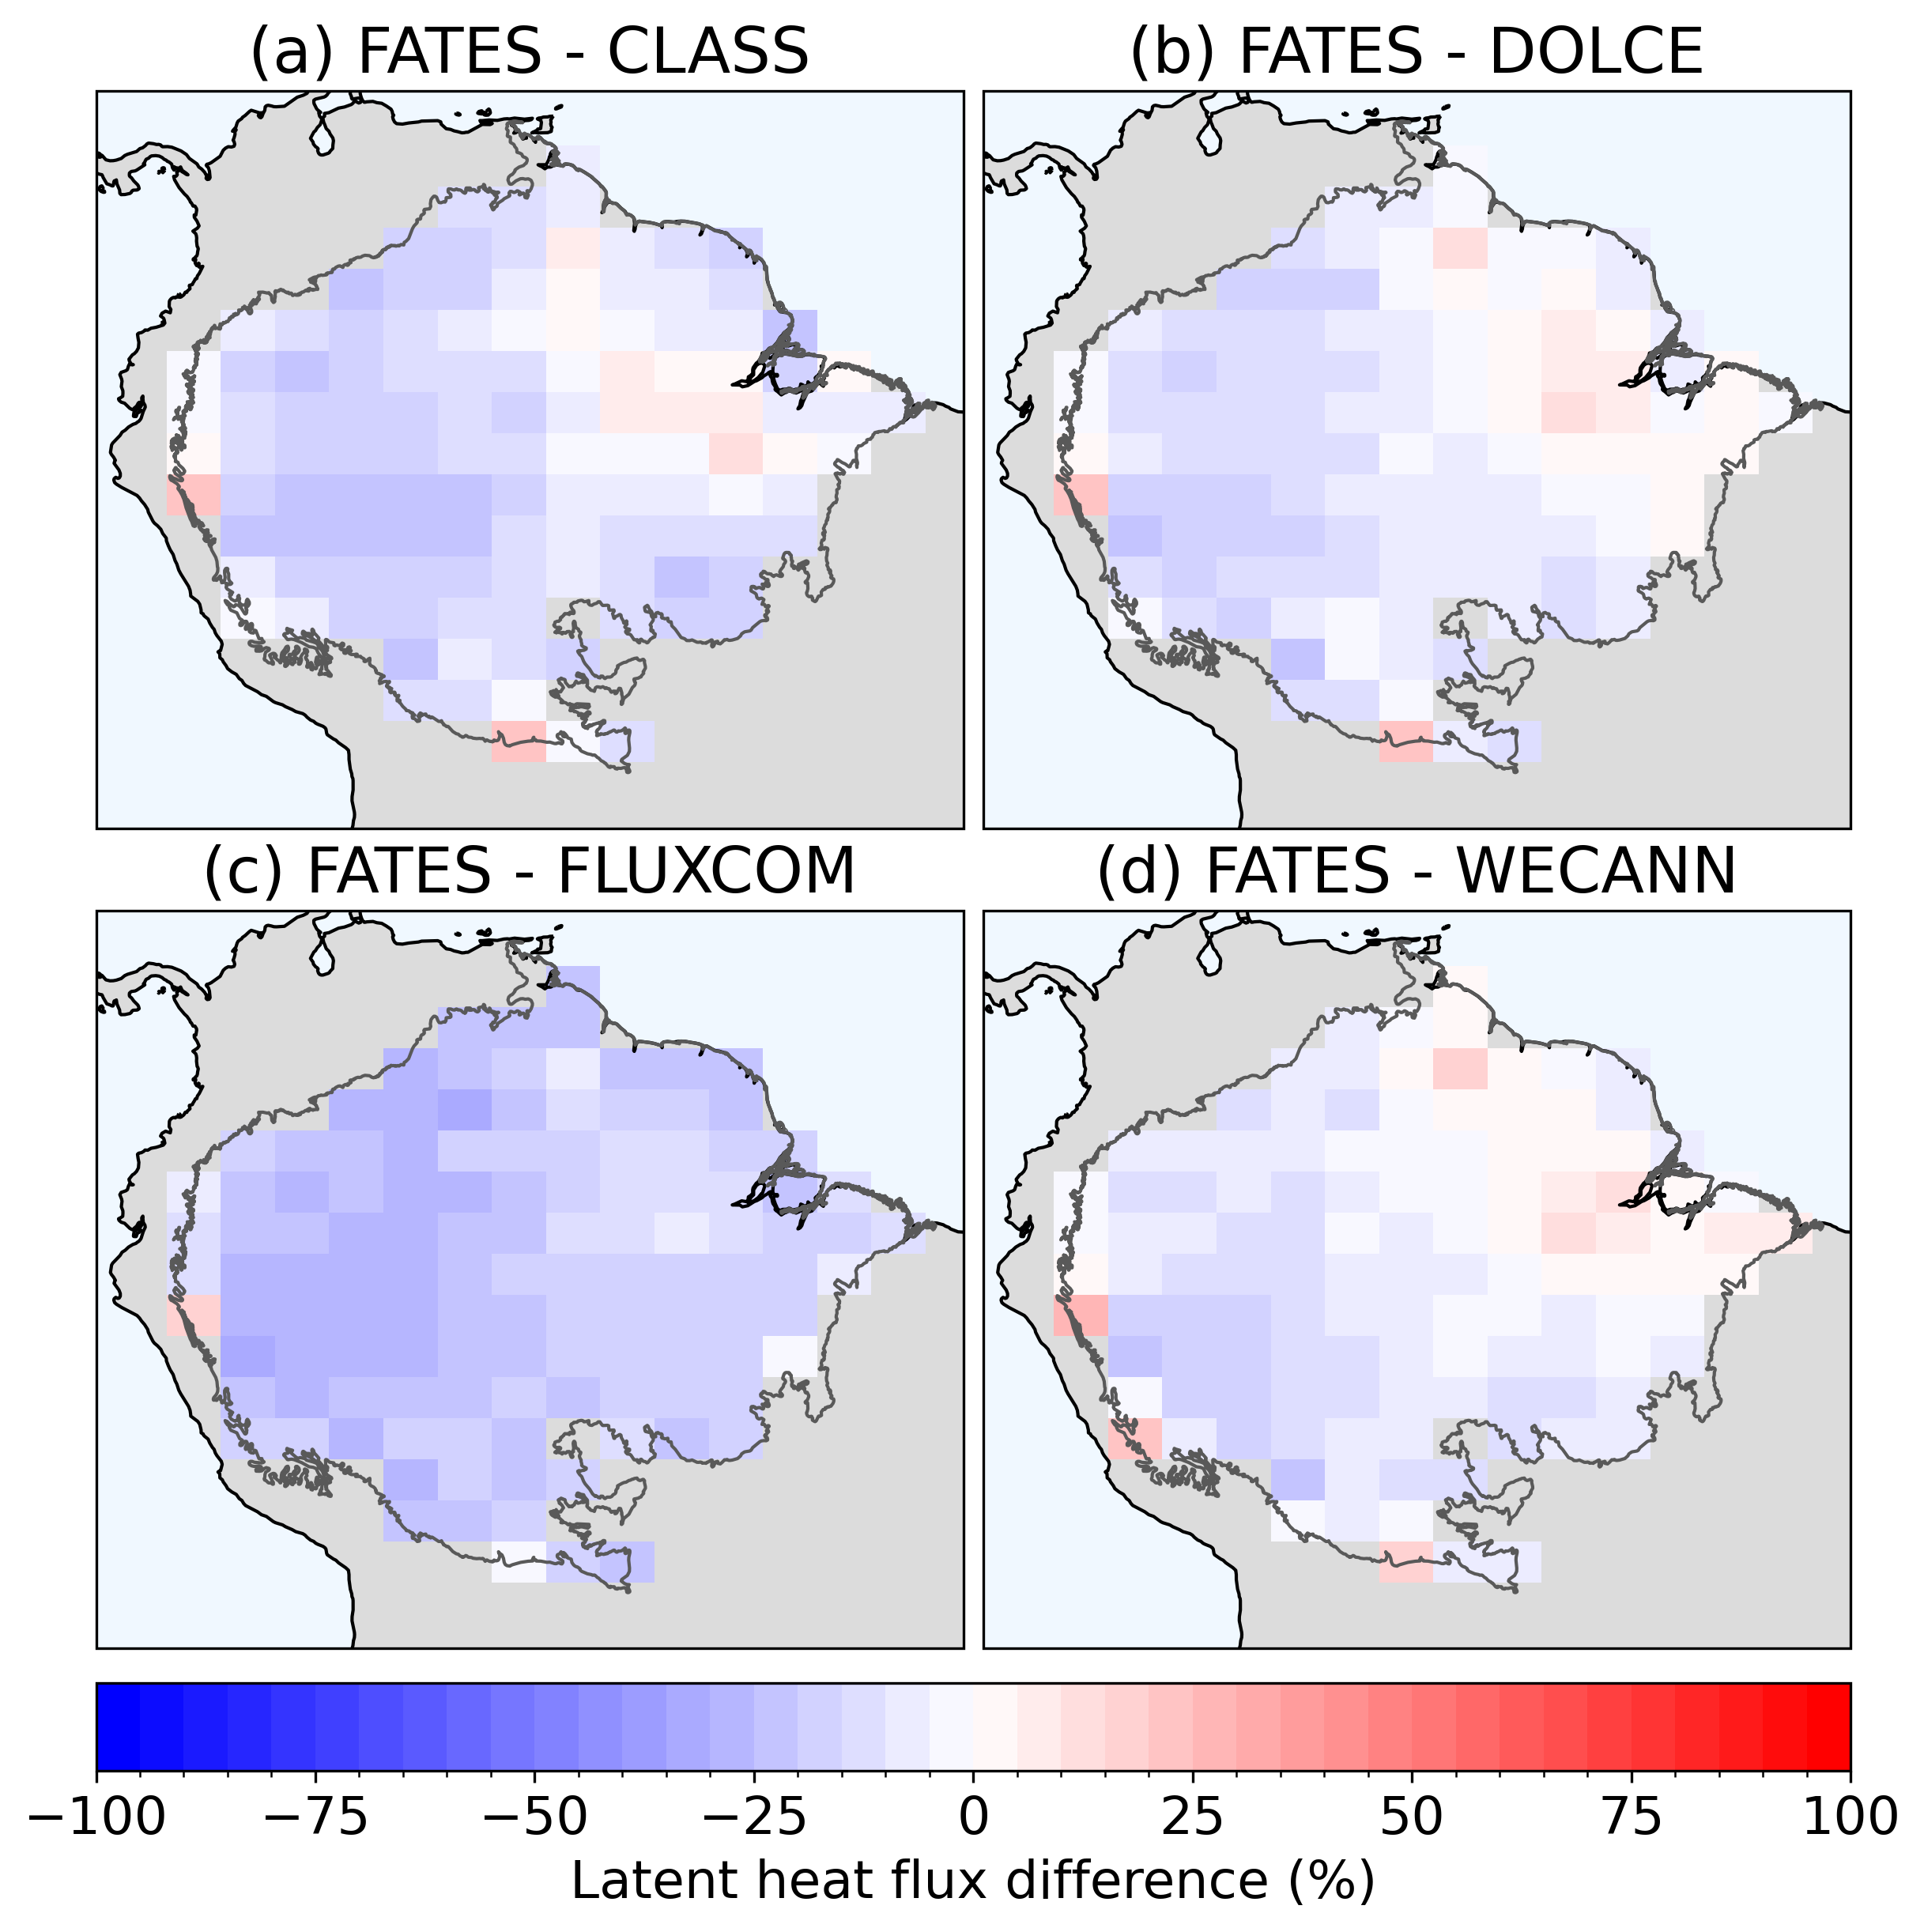

In [93]:
# Make a 4 panel figure for LH % differences

# Create figure with 2 subplots (2 row, 2 columns)
fig, axes = plt.subplots(
    2,
    2,
    figsize=(8, 8),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=True,
)

ax1, ax2, ax3, ax4 = axes.flatten()

levels = np.linspace(-100, 100, 41)

# First panel: (FATES - CLASS)/CLASS
class_diff = 100 * (fates_lh - class_lh) / class_lh
im1 = class_diff.hfls.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax1,
    add_colorbar=False,  # Turn off individual colorbar
)
ax1.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax1.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax1.set_title("(a) FATES - CLASS")
ax1.coastlines()
ax1.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax1.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax1.set_ylim([min_lat_plotting, max_lat_plotting])

# Second panel: (FATES - DOLCE)/DOLCE
dolce_diff = 100 * (fates_lh - dolce_lh) / dolce_lh
im2 = dolce_diff.hfls.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax2,
    add_colorbar=False,  # Turn off individual colorbar
)
ax2.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax2.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax2.set_title("(b) FATES - DOLCE")
ax2.coastlines()
ax2.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax2.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax2.set_ylim([min_lat_plotting, max_lat_plotting])

# Third panel: (FATES - FLUXCOM)/FLUXCOM
fluxcom_diff = 100 * (fates_lh - fluxcom_lh) / fluxcom_lh
im3 = fluxcom_diff.le.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax3,
    add_colorbar=False,  # Turn off individual colorbar
)
ax3.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax3.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax3.set_title("(c) FATES - FLUXCOM")
ax3.coastlines()
ax3.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax3.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax3.set_ylim([min_lat_plotting, max_lat_plotting])

# Fourth panel: (FATES - WECANN)/WECANN
wecann_diff = 100 * (fates_lh - wecann_lh) / wecann_lh
im4 = wecann_diff.hfls.where(fates_Amazon_mask > 0).plot(
    x="lon",
    y="lat",
    cmap=plt.cm.bwr,
    levels=levels,
    transform=ccrs.PlateCarree(),
    ax=ax4,
    add_colorbar=False,  # Turn off individual colorbar
)
ax4.add_feature(cartopy.feature.LAND, facecolor="gainsboro", zorder=0)
ax4.add_feature(cartopy.feature.OCEAN, facecolor="aliceblue", zorder=0)
ax4.set_title("(d) FATES - WECANN")
ax4.coastlines()
ax4.add_geometries(
    Reader(Amazon_shapefile).geometries(),
    ccrs.PlateCarree(),
    edgecolor=(0.35, 0.35, 0.35, 1),
    facecolor=(0, 0, 0, 0),
)
ax4.set_xlim([min_lon_plotting - 360.0, max_lon_plotting - 360.0])
ax4.set_ylim([min_lat_plotting, max_lat_plotting])

# Add single shared colorbar spanning all subplots
cbar = fig.colorbar(
    im1,
    ax=axes,
    orientation="horizontal",
    shrink=1,
    pad=0.02,
    label="Latent heat flux difference (%)",
)

In [95]:
# stats for all LH

np.nanmean(np.concatenate((class_diff.hfls.where(fates_Amazon_mask > 0).data,dolce_diff.hfls.where(fates_Amazon_mask > 0).data,fluxcom_diff.le.where(fates_Amazon_mask > 0).data,wecann_diff.hfls.where(fates_Amazon_mask > 0).data)))

-10.381494498623953

In [96]:
np.nanstd(np.concatenate((class_diff.hfls.where(fates_Amazon_mask > 0).data,dolce_diff.hfls.where(fates_Amazon_mask > 0).data,fluxcom_diff.le.where(fates_Amazon_mask > 0).data,wecann_diff.hfls.where(fates_Amazon_mask > 0).data)))

9.828518769698388

In [71]:
# Stats
np.mean(wecann_diff.hfls.where(fates_Amazon_mask > 0))


<xarray.DataArray 'hfls' ()>
array(-4.96237967)

In [69]:
np.mean(fluxcom_diff.le.where(fates_Amazon_mask > 0))


<xarray.DataArray 'le' ()>
array(-19.56544204)

In [72]:
np.std(wecann_diff.hfls.where(fates_Amazon_mask > 0))


<xarray.DataArray 'hfls' ()>
array(8.39397192)

In [70]:
np.std(fluxcom_diff.le.where(fates_Amazon_mask > 0))


<xarray.DataArray 'le' ()>
array(6.62384191)